# ✈️ Proyecto ML:
### Predicción de Satisfacción: Análisis Inteligente de Experiencia de Vuelo

## 📌 Contexto del Proyecto
En un mercado tan competitivo como el sector aeroportuario, la satisfacción del cliente es el principal motor de fidelización. Este proyecto aplica técnicas avanzadas de **Machine Learning** para analizar y predecir la experiencia del pasajero basándose en múltiples puntos de contacto, desde el confort del asiento hasta la calidad del servicio digital.

---

## 🛠️ Hoja de Ruta del Análisis

A continuación, el documento se desarrolla a través de las siguientes fases clave:

### 1. Diagnóstico de Datos (EDA Dirigido)
No solo cargamos datos; los entendemos. Analizamos la **variable objetivo** para detectar desequilibrios y estudiamos la **correlación de servicios** para entender cómo influyen factores como el WiFi o el retraso en la percepción final del cliente.


### 2. Ingeniería de Datos mediante Pipelines
Para garantizar una resolución sensata y profesional, hemos construido una **Línea de Montaje (Pipeline)** de datos que realiza:
* **Imputación Inteligente:** Tratamiento automático de valores nulos.
* **Codificación y Escalado:** Transformación de variables categóricas y normalización de variables numéricas para optimizar el rendimiento del algoritmo.
* **Prevención de Fuga (Data Leakage):** Aseguramos que el preprocesamiento sea ciego a los datos de test, garantizando resultados honestos.


### 3. Modelado con Random Forest
Hemos seleccionado el algoritmo **Random Forest** por su robustez ante valores atípicos (outliers) y su capacidad para capturar patrones complejos que otros modelos lineales ignorarían.


### 4. Evaluación y Valor de Negocio
El éxito no se mide solo en precisión. Evaluamos el modelo mediante:
* **Matrices de Confusión:** Para entender dónde falla el modelo y por qué.
* **Análisis de Importancia de Variables:** Identificamos qué servicios específicos debe mejorar la aerolínea para aumentar su tasa de clientes satisfechos.


### 5. Persistencia y Simulador en Vivo
El proyecto concluye con la exportación del modelo mediante `joblib` y la creación de un **entorno de simulación**, donde podemos testear escenarios hipotéticos con pasajeros nuevos en tiempo real.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split

# Estética para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar datasets
train_df = pd.read_csv('src/data_sample/train.csv').drop(columns=['Unnamed: 0', 'id'], errors='ignore')
test_df = pd.read_csv('src/data_sample/test.csv').drop(columns=['Unnamed: 0', 'id'], errors='ignore')

print(f"Train: {train_df.shape}, Test: {test_df.shape}")
train_df.head()

Train: (103904, 23), Test: (25976, 23)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


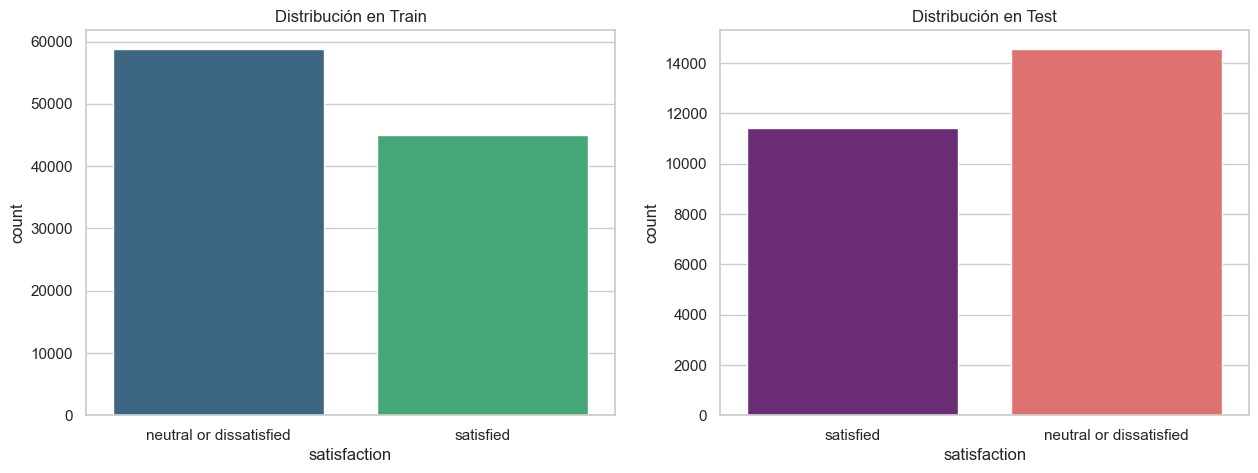

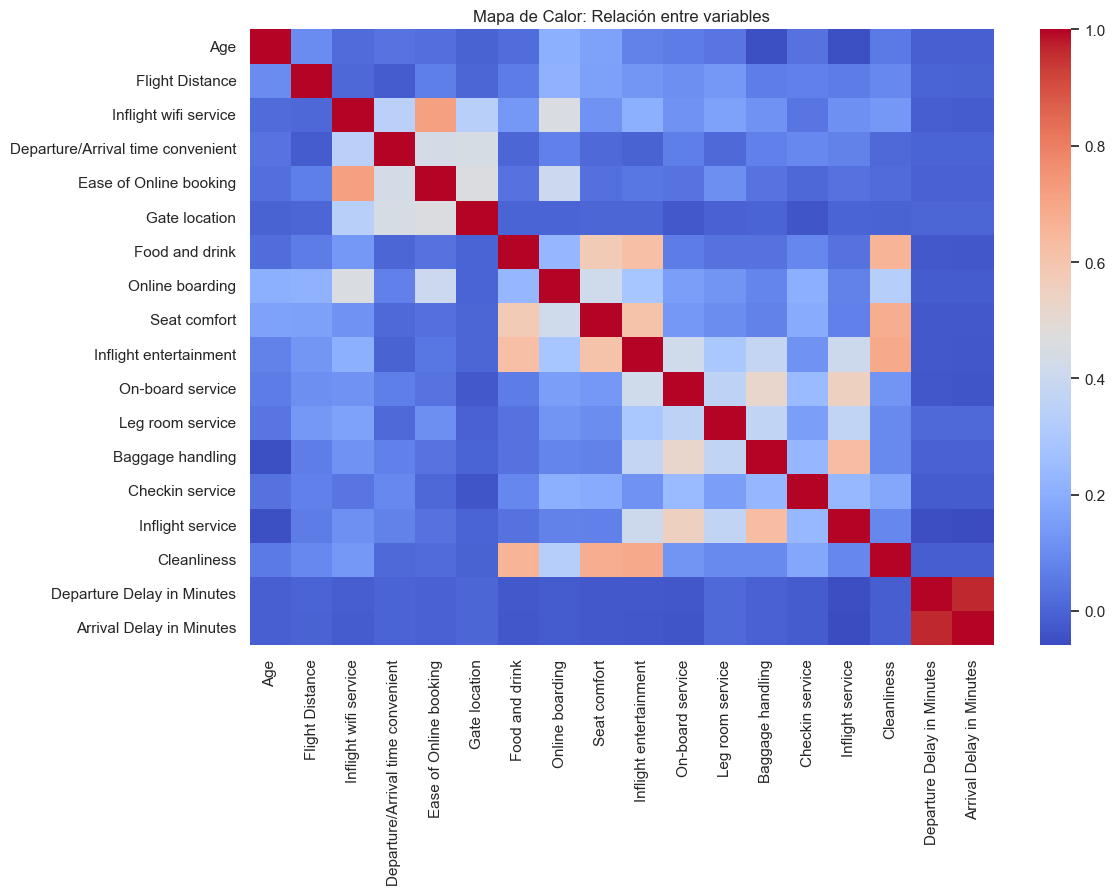

In [2]:
# EDA dirigido
 
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=train_df, x='satisfaction', hue='satisfaction', ax=ax[0], palette='viridis', legend=False).set_title('Distribución en Train')
sns.countplot(data=test_df, x='satisfaction', hue='satisfaction', ax=ax[1], palette='magma', legend=False).set_title('Distribución en Test')

plt.figure(figsize=(12, 8))
corr = train_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Mapa de Calor: Relación entre variables')
plt.show()

In [3]:
# Construcción del pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Separar X e y
X_train = train_df.drop(columns=['satisfaction'])
y_train = train_df['satisfaction']
X_test = test_df.drop(columns=['satisfaction'])
y_test = test_df['satisfaction']

# Definir tipos de columnas
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Procesamiento por tipo
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Unir en el preprocesador
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Pipeline Final
main_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
])

# ENTRENAMIENTO
main_pipeline.fit(X_train, y_train)
print("Pipeline entrenado y listo.")

C:\Users\daniel.m\AppData\Local\Temp\ipykernel_19928\611278565.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


Pipeline entrenado y listo.



INFORME DE RENDIMIENTO
                         precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.97      0.97     14573
              satisfied       0.97      0.95      0.95     11403

               accuracy                           0.96     25976
              macro avg       0.96      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976



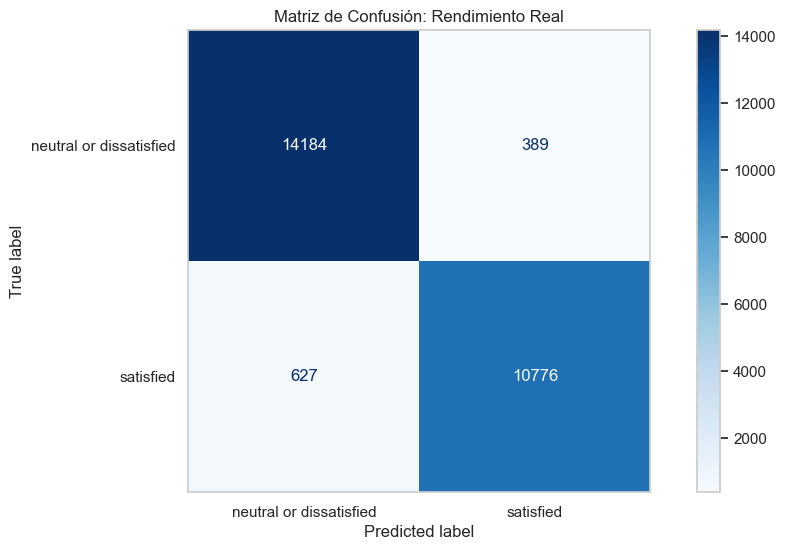

In [8]:
# Evaluación de resultados

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = main_pipeline.predict(X_test)

print("\nINFORME DE RENDIMIENTO")
print(classification_report(y_test, y_pred))

# Matriz de Confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Matriz de Confusión: Rendimiento Real')
plt.grid(False)
plt.show()

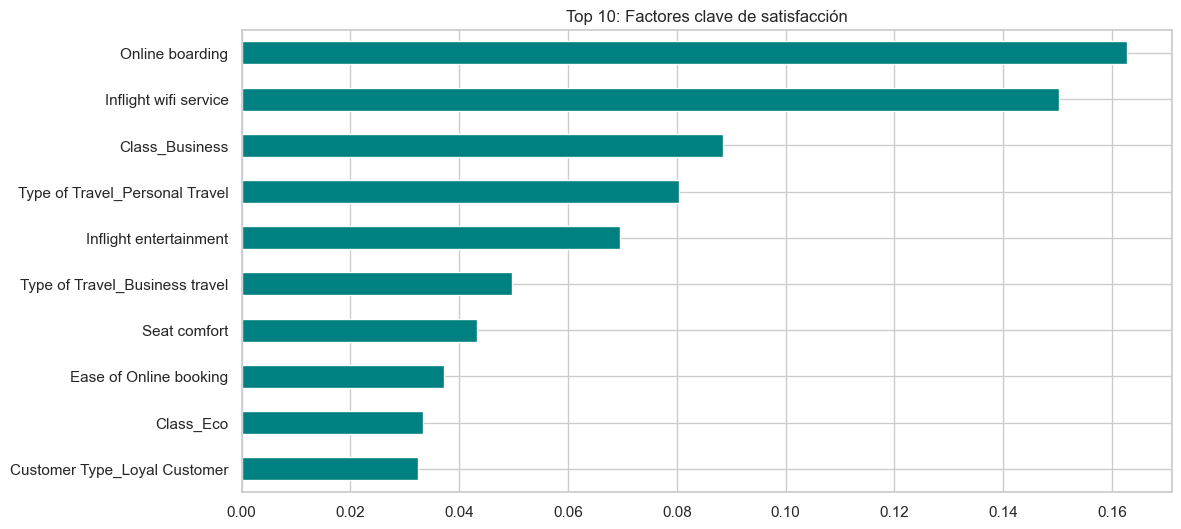

In [5]:
# Análisis de negocio

cat_names = main_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(cat_cols)
features = num_cols + list(cat_names)
importances = main_pipeline.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False).head(10)
feat_imp.plot(kind='barh', color='teal').invert_yaxis()
plt.title('Top 10: Factores clave de satisfacción')
plt.show()

In [6]:
# Guardado del modelo joblib
 
model_path = 'src/models/'
if not os.path.exists(model_path):
    os.makedirs(model_path)

model_file = os.path.join(model_path, 'model_final_airline.joblib')
joblib.dump(main_pipeline, model_file)

print(f"Proyecto guardado en: {model_file}!")

Proyecto guardado en: src/models/model_final_airline.joblib!


In [ ]:
# Simulador

predictor = joblib.load('src/models/model_final_airline.joblib')

def simular_pasajero(cambios):
    base = test_df.drop(columns=['satisfaction']).iloc[[0]].copy()
    for col, val in cambios.items():
        base[col] = val
    return base

nuevo = simular_pasajero({'Age': 18, 'Class': 'Business', 'Inflight wifi service': 1})
resultado = predictor.predict(nuevo)
print(f"La IA predice que el cliente estará: {resultado[0].upper()}")

La IA predice que el cliente estará: SATISFIED
